In [173]:
import numpy as np
import matplotlib.pyplot as plt

# Project 2 - Hospital
*Adam Bøttcher Haupt-Hansen*

In [174]:
def rate1(t):
    return max(0.0, -(1/3650) * t**2 + (1/10) * t)

def rate2(t):
    return (1/5) * rate1(t)

RATE1_MAX = 9.125  # peak of rate1(t), at its vertex t = 182.5
RATE2_MAX = RATE1_MAX / 5

def lam1(t):
    # Thinning (Lewis-Shedler) algorithm: propose at the peak rate, accept/reject by the true local rate.
    # Avoids drawing absurd inter-arrival times near t=0, where rate1(t) is close to zero.
    t0 = t
    while True:
        t += np.random.exponential(1 / RATE1_MAX)
        if t >= 365 or np.random.uniform() <= rate1(t) / RATE1_MAX:
            return t - t0

def lam2(t):
    t0 = t
    while True:
        t += np.random.exponential(1 / RATE2_MAX)
        if t >= 365 or np.random.uniform() <= rate2(t) / RATE2_MAX:
            return t - t0

def lam3(t):
    return np.random.exponential(1 / 6)

In [175]:
def los1():
    return np.random.lognormal(mean=np.log(4 * np.sqrt(2)), sigma=np.log(2))
def los2():
    return np.random.lognormal(mean=np.log(6 * np.sqrt(2)), sigma=np.log(2))
def los3():
    return np.random.lognormal(mean=np.log(5 * np.sqrt(2)), sigma=np.log(2))

In [176]:
def simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time):
    t = 1e-6  # Start time, avoid zero to prevent issues with arrival rate functions
    total_capacities = list(ward_capacities)
    ward_capacities = list(ward_capacities)  # local copy so the caller's list isn't mutated
    n_wards = len(ward_capacities)
    event_queue = []
    ward_arrivals = {ward: 0 for ward in range(n_wards)}
    ward_rejected = {ward: 0 for ward in range(n_wards)}
    # occupancy_history[ward] holds (time, beds_occupied) recorded on every admit/departure
    occupancy_history = {ward: [(0.0, 0)] for ward in range(n_wards)}
    # rejection_times[ward] holds the time of every rejected arrival
    rejection_times = {ward: [] for ward in range(n_wards)}

    # Initialize the event queue with the first arrival for each ward
    for ward in range(n_wards):
        event_queue.append((t + arrival_rates[ward](t), 'arrival', ward))
    # Sort the event queue by time
    event_queue.sort(key=lambda x: x[0])

    #Begin simulation loop
    while event_queue and event_queue[0][0] < simulation_time:
        # Get the next event
        t, event_type, ward = event_queue.pop(0)

        if event_type == 'arrival':
            ward_arrivals[ward] += 1
            # Check if the ward has capacity
            if ward_capacities[ward] > 0:
                # Admit the patient and schedule a departure
                ward_capacities[ward] -= 1
                occupancy_history[ward].append((t, total_capacities[ward] - ward_capacities[ward]))
                service_time = service_rates[ward]()
                event_queue.append((t + service_time, 'departure', ward))
            else:
                if ward == 1 and ward_capacities[0] > 0:
                    # Ward 1 is full, but Ward 0 has capacity, redirect the patient
                    ward_capacities[0] -= 1
                    occupancy_history[0].append((t, total_capacities[0] - ward_capacities[0]))
                    service_time = service_rates[0]()
                    event_queue.append((t + service_time, 'departure', 0))
                else:
                    # Ward is full, reject the patient
                    ward_rejected[ward] += 1
                    rejection_times[ward].append(t)

            # Schedule the next arrival for this ward
            next_arrival_time = t + arrival_rates[ward](t)
            event_queue.append((next_arrival_time, 'arrival', ward))
            event_queue.sort(key=lambda x: x[0])
        else:
            # Departure event, free up the ward capacity
            ward_capacities[ward] += 1
            occupancy_history[ward].append((t, total_capacities[ward] - ward_capacities[ward]))

    return ward_rejected, ward_arrivals, occupancy_history, rejection_times

In [177]:
ward_capacities = [15, 10, 50]
arrival_rates = [lam1, lam2, lam3]
service_rates = [los1, los2, los3]

In [178]:
simulation_time = 365  # Simulate for one year
ward_rejected, ward_arrivals, occupancy_history, rejection_times = simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time)
rejection_rate = {ward: ward_rejected[ward] / ward_arrivals[ward] for ward in ward_rejected}
print("Rejection rate in each ward:", {ward: round(rate, 4) for ward, rate in rejection_rate.items()})

Rejection rate in each ward: {0: 0.6899, 1: 0.2839, 2: 0.1458}


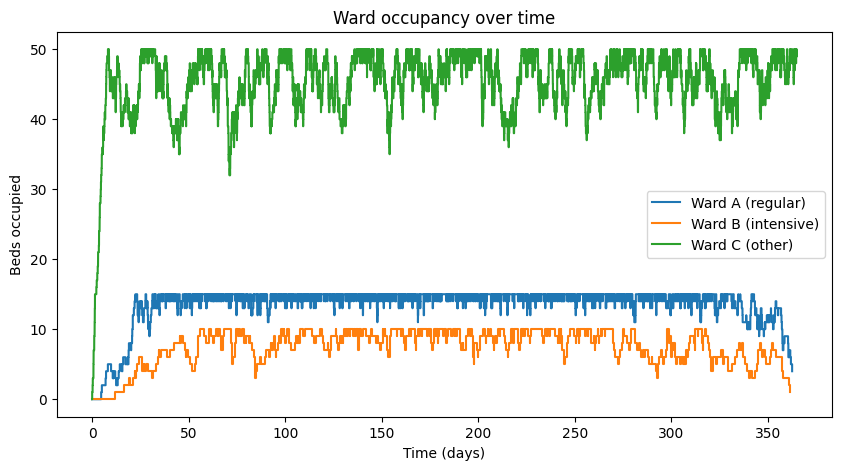

In [179]:
ward_names = ['Ward A (regular)', 'Ward B (intensive)', 'Ward C (other)']

fig, ax = plt.subplots(figsize=(10, 5))
for ward, history in occupancy_history.items():
    times, occupied = zip(*history)
    ax.step(times, occupied, where='post', label=ward_names[ward])
ax.set_xlabel('Time (days)')
ax.set_ylabel('Beds occupied')
ax.set_title('Ward occupancy over time')
ax.legend()
plt.show()

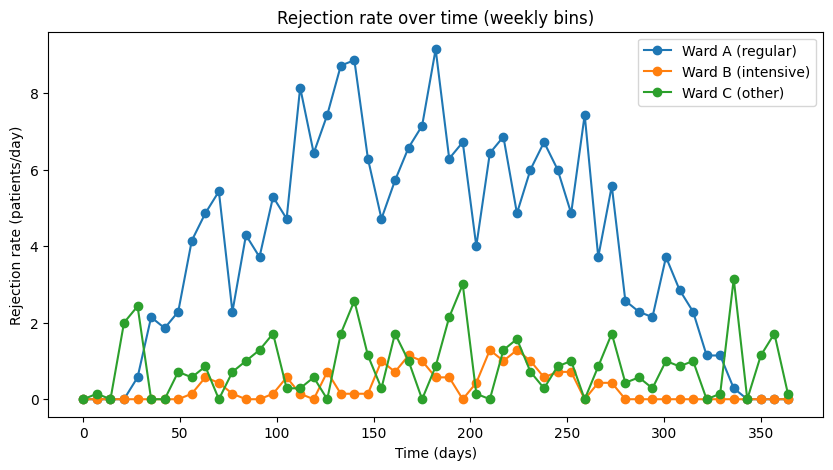

In [180]:
bin_width = 7  # days per bin
bins = np.arange(0, simulation_time + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(10, 5))
for ward, times in rejection_times.items():
    counts, _ = np.histogram(times, bins=bins)
    binned_rejection_rate = counts / bin_width  # rejected patients per day, within each bin
    ax.plot(bins[:-1], binned_rejection_rate, marker='o', label=ward_names[ward])
ax.set_xlabel('Time (days)')
ax.set_ylabel('Rejection rate (patients/day)')
ax.set_title('Rejection rate over time (weekly bins)')
ax.legend()
plt.show()

## Sensitivity: exponential LOS instead of lognormal

Same mean length-of-stay per ward (8, 12, 10 days), but exponentially distributed instead of lognormal.

In [181]:
def los1_exp():
    return np.random.exponential(scale=8)
def los2_exp():
    return np.random.exponential(scale=12)
def los3_exp():
    return np.random.exponential(scale=10)

service_rates_exp = [los1_exp, los2_exp, los3_exp]
ward_rejected_exp, ward_arrivals_exp, occupancy_history_exp, rejection_times_exp = simulate_hospital(
    arrival_rates, service_rates_exp, ward_capacities, simulation_time
)
rejection_rate_exp = {ward: ward_rejected_exp[ward] / ward_arrivals_exp[ward] for ward in ward_rejected_exp}

print("Rejection rate in each ward (lognormal LOS):  ", {ward: round(rate, 4) for ward, rate in rejection_rate.items()})
print("Rejection rate in each ward (exponential LOS):", {ward: round(rate, 4) for ward, rate in rejection_rate_exp.items()})

Rejection rate in each ward (lognormal LOS):   {0: 0.6899, 1: 0.2839, 2: 0.1458}
Rejection rate in each ward (exponential LOS): {0: 0.7392, 1: 0.3566, 2: 0.2468}


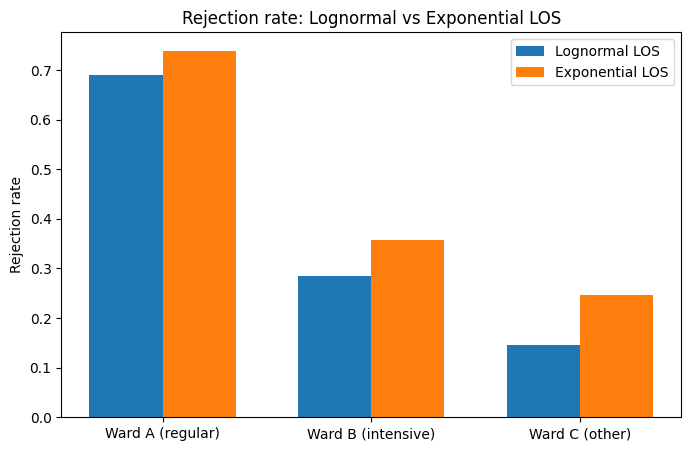

In [182]:
n_wards = len(ward_names)
x = np.arange(n_wards)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, [rejection_rate[w] for w in range(n_wards)], width, label='Lognormal LOS')
ax.bar(x + width/2, [rejection_rate_exp[w] for w in range(n_wards)], width, label='Exponential LOS')
ax.set_xticks(x)
ax.set_xticklabels(ward_names)
ax.set_ylabel('Rejection rate')
ax.set_title('Rejection rate: Lognormal vs Exponential LOS')
ax.legend()
plt.show()

## Statistical test: is the difference in rejections significant?

In [183]:
from scipy import stats

n_reps = 200
rate_log = {ward: [] for ward in range(n_wards)}
rate_exp = {ward: [] for ward in range(n_wards)}

for _ in range(n_reps):
    rej_log, arr_log, _, _ = simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time)
    rej_exp, arr_exp, _, _ = simulate_hospital(arrival_rates, service_rates_exp, ward_capacities, simulation_time)
    for ward in range(n_wards):
        rate_log[ward].append(rej_log[ward] / arr_log[ward])
        rate_exp[ward].append(rej_exp[ward] / arr_exp[ward])

# Overall rate per replication: total rejected over total arrivals, across all wards
total_rate_log = [sum(rate_log[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]
total_rate_exp = [sum(rate_exp[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]

In [184]:
def report_test(name, sample_a, sample_b, label_a='A', label_b='B'):
    t_stat, p_t = stats.ttest_ind(sample_a, sample_b, equal_var=False)  # Welch's t-test
    u_stat, p_u = stats.mannwhitneyu(sample_a, sample_b, alternative='two-sided')
    print(f"{name}:")
    print(f"  {label_a}: mean={np.mean(sample_a):.4f}  std={np.std(sample_a, ddof=1):.4f}")
    print(f"  {label_b}: mean={np.mean(sample_b):.4f}  std={np.std(sample_b, ddof=1):.4f}")
    print(f"  Welch's t-test:    t={t_stat:.3f}, p={p_t:.4f}")
    print(f"  Mann-Whitney U:    U={u_stat:.1f}, p={p_u}")
    print(f"  Significant at 5%? {'yes' if p_t < 0.05 else 'no'}")
    print()

for ward in range(n_wards):
    report_test(ward_names[ward], rate_log[ward], rate_exp[ward], 'Lognormal', 'Exponential')
report_test("Average rejection rate (all wards)", total_rate_log, total_rate_exp, 'Lognormal', 'Exponential')

Ward A (regular):
  Lognormal: mean=0.7078  std=0.0107
  Exponential: mean=0.7353  std=0.0117
  Welch's t-test:    t=-24.423, p=0.0000
  Mann-Whitney U:    U=1617.5, p=6.395325916228259e-57
  Significant at 5%? yes

Ward B (intensive):
  Lognormal: mean=0.3188  std=0.0276
  Exponential: mean=0.3601  std=0.0327
  Welch's t-test:    t=-13.687, p=0.0000
  Mann-Whitney U:    U=6674.0, p=9.776089215809666e-31
  Significant at 5%? yes

Ward C (other):
  Lognormal: mean=0.1453  std=0.0171
  Exponential: mean=0.2071  std=0.0214
  Welch's t-test:    t=-31.921, p=0.0000
  Mann-Whitney U:    U=514.0, p=9.824414017954762e-64
  Significant at 5%? yes

Average rejection rate (all wards):
  Lognormal: mean=0.3906  std=0.0122
  Exponential: mean=0.4342  std=0.0140
  Welch's t-test:    t=-33.204, p=0.0000
  Mann-Whitney U:    U=415.0, p=2.3001959737234196e-64
  Significant at 5%? yes



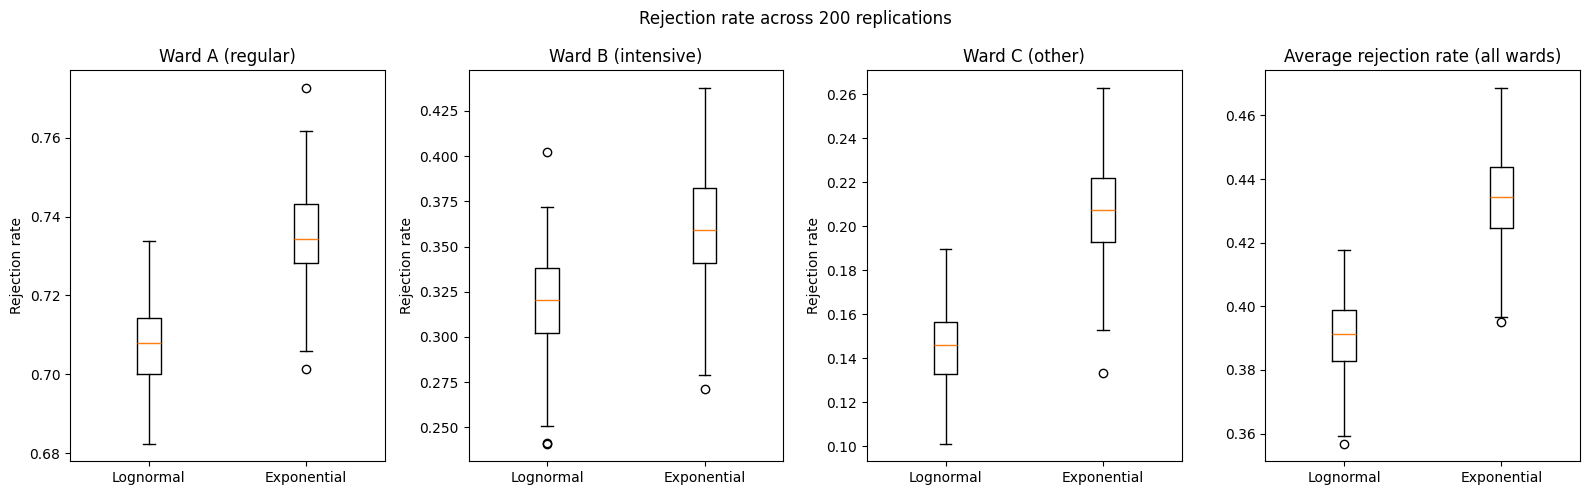

In [185]:
fig, axes = plt.subplots(1, n_wards + 1, figsize=(4 * (n_wards + 1), 5), sharey=False)
for ward in range(n_wards):
    axes[ward].boxplot([rate_log[ward], rate_exp[ward]], tick_labels=['Lognormal', 'Exponential'])
    axes[ward].set_title(ward_names[ward])
    axes[ward].set_ylabel('Rejection rate')
axes[-1].boxplot([total_rate_log, total_rate_exp], tick_labels=['Lognormal', 'Exponential'])
axes[-1].set_title('Average rejection rate (all wards)')
fig.suptitle(f'Rejection rate across {n_reps} replications')
plt.tight_layout()
plt.show()

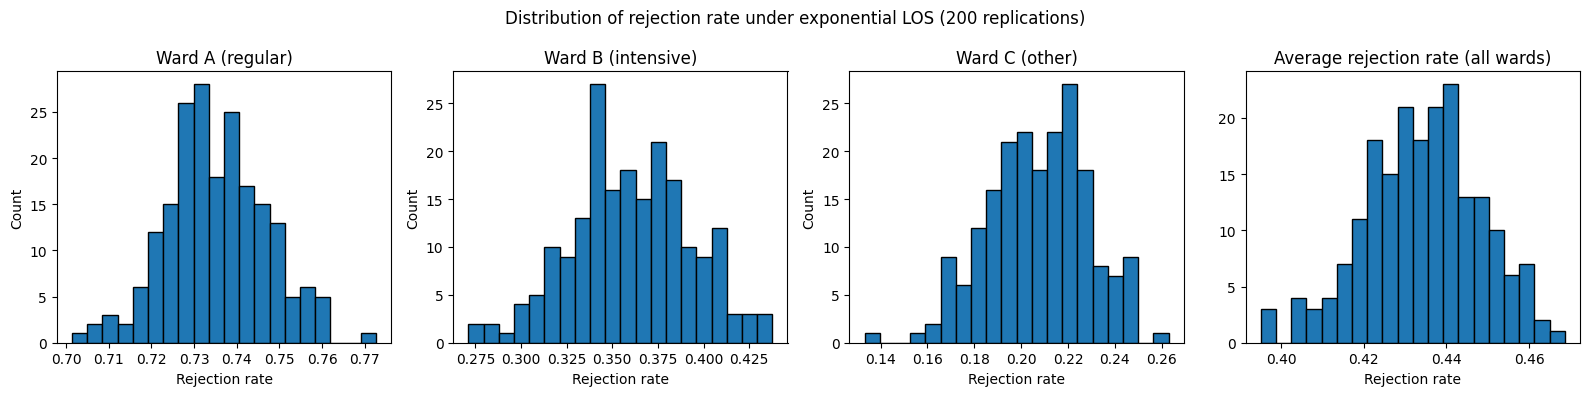

In [186]:
fig, axes = plt.subplots(1, n_wards + 1, figsize=(4 * (n_wards + 1), 4), sharey=False)
for ward in range(n_wards):
    axes[ward].hist(rate_exp[ward], bins=20, edgecolor='black')
    axes[ward].set_title(ward_names[ward])
    axes[ward].set_xlabel('Rejection rate')
    axes[ward].set_ylabel('Count')
axes[-1].hist(total_rate_exp, bins=20, edgecolor='black')
axes[-1].set_title('Average rejection rate (all wards)')
axes[-1].set_xlabel('Rejection rate')
fig.suptitle(f'Distribution of rejection rate under exponential LOS ({n_reps} replications)')
plt.tight_layout()
plt.show()

## Sensitivity: extra beds

Same bed ratio as the baseline `[15, 10, 50]`, scaled up to 90 beds total: `[18, 12, 60]`.

In [187]:
new_capacities = [18, 12, 60]  # same ratio as [15, 10, 50], scaled to 90 beds total

In [188]:
ward_rejected_new, ward_arrivals_new, occupancy_history_new, rejection_times_new = simulate_hospital(
    arrival_rates, service_rates, new_capacities, simulation_time
)
rejection_rate_new = {ward: ward_rejected_new[ward] / ward_arrivals_new[ward] for ward in ward_rejected_new}

print("Rejection rate in each ward (75 beds, [15,10,50]):", {ward: round(rate, 4) for ward, rate in rejection_rate.items()})
print("Rejection rate in each ward (90 beds, [18,12,60]):", {ward: round(rate, 4) for ward, rate in rejection_rate_new.items()})

Rejection rate in each ward (75 beds, [15,10,50]): {0: 0.6899, 1: 0.2839, 2: 0.1458}
Rejection rate in each ward (90 beds, [18,12,60]): {0: 0.6643, 1: 0.2426, 2: 0.0517}


In [189]:
rate_base = {ward: [] for ward in range(n_wards)}
rate_new = {ward: [] for ward in range(n_wards)}

for _ in range(n_reps):
    rej_base, arr_base, _, _ = simulate_hospital(arrival_rates, service_rates, ward_capacities, simulation_time)
    rej_new, arr_new, _, _ = simulate_hospital(arrival_rates, service_rates, new_capacities, simulation_time)
    for ward in range(n_wards):
        rate_base[ward].append(rej_base[ward] / arr_base[ward])
        rate_new[ward].append(rej_new[ward] / arr_new[ward])

total_rate_base = [sum(rate_base[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]
total_rate_new = [sum(rate_new[ward][i] for ward in range(n_wards)) / n_wards for i in range(n_reps)]

for ward in range(n_wards):
    report_test(ward_names[ward], rate_base[ward], rate_new[ward], '75 beds', '90 beds')
report_test("Average rejection rate (all wards)", total_rate_base, total_rate_new, '75 beds', '90 beds')

Ward A (regular):
  75 beds: mean=0.7087  std=0.0110
  90 beds: mean=0.6483  std=0.0108
  Welch's t-test:    t=55.426, p=0.0000
  Mann-Whitney U:    U=40000.0, p=4.830448488384059e-67
  Significant at 5%? yes

Ward B (intensive):
  75 beds: mean=0.3172  std=0.0265
  90 beds: mean=0.2374  std=0.0269
  Welch's t-test:    t=29.861, p=0.0000
  Mann-Whitney U:    U=39208.0, p=5.570077397537998e-62
  Significant at 5%? yes

Ward C (other):
  75 beds: mean=0.1416  std=0.0174
  90 beds: mean=0.0435  std=0.0120
  Welch's t-test:    t=65.597, p=0.0000
  Mann-Whitney U:    U=40000.0, p=4.830652435142516e-67
  Significant at 5%? yes

Average rejection rate (all wards):
  75 beds: mean=0.3892  std=0.0115
  90 beds: mean=0.3097  std=0.0109
  Welch's t-test:    t=70.766, p=0.0000
  Mann-Whitney U:    U=40000.0, p=4.830856390397399e-67
  Significant at 5%? yes



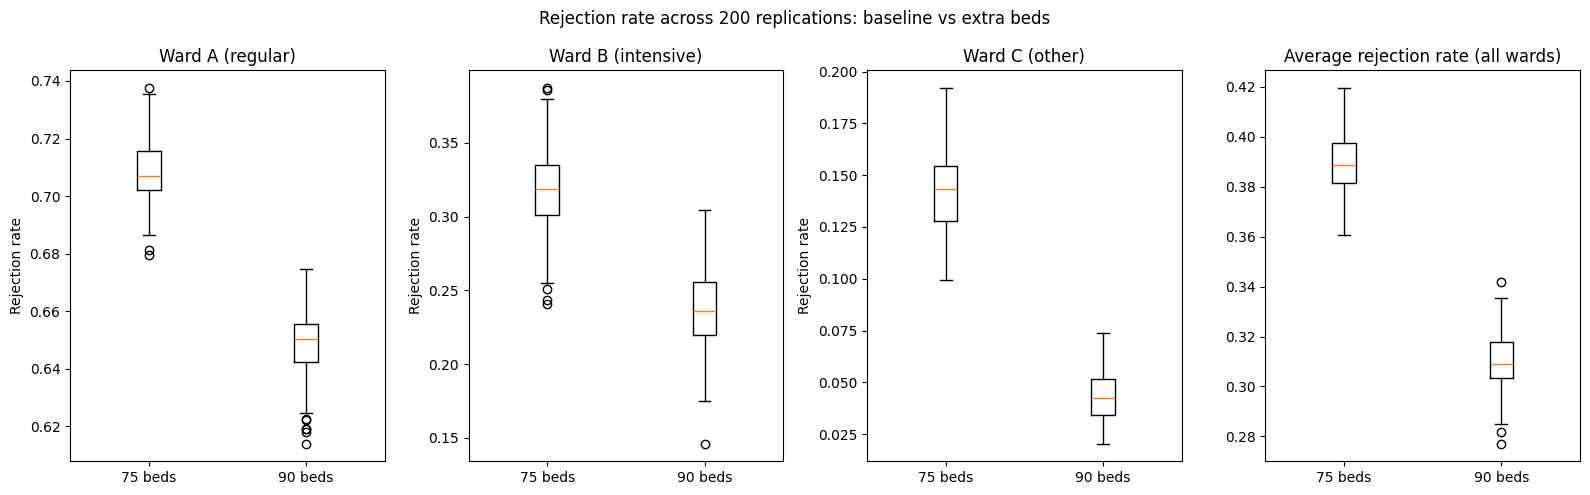

In [190]:
fig, axes = plt.subplots(1, n_wards + 1, figsize=(4 * (n_wards + 1), 5), sharey=False)
for ward in range(n_wards):
    axes[ward].boxplot([rate_base[ward], rate_new[ward]], tick_labels=['75 beds', '90 beds'])
    axes[ward].set_title(ward_names[ward])
    axes[ward].set_ylabel('Rejection rate')
axes[-1].boxplot([total_rate_base, total_rate_new], tick_labels=['75 beds', '90 beds'])
axes[-1].set_title('Average rejection rate (all wards)')
fig.suptitle(f'Rejection rate across {n_reps} replications: baseline vs extra beds')
plt.tight_layout()
plt.show()

## Sensitivity: rejection rate vs total number of beds

Sweep the total bed count, keeping the same ward ratio as the baseline `[15, 10, 50]`, and track how the overall rejection rate changes.

In [191]:
bed_ratio = np.array(ward_capacities) / sum(ward_capacities)
total_beds_range = np.arange(30, 151, 10)
n_reps_sweep = 30

sweep_mean = []
sweep_se = []

for total_beds in total_beds_range:
    capacities = np.round(bed_ratio * total_beds).astype(int)
    reps = []
    for _ in range(n_reps_sweep):
        rej, arr, _, _ = simulate_hospital(arrival_rates, service_rates, capacities, simulation_time)
        overall_rate = np.mean([rej[ward] / arr[ward] for ward in range(n_wards)])
        reps.append(overall_rate)
    sweep_mean.append(np.mean(reps))
    sweep_se.append(np.std(reps, ddof=1) / np.sqrt(n_reps_sweep))

sweep_mean = np.array(sweep_mean)
sweep_se = np.array(sweep_se)

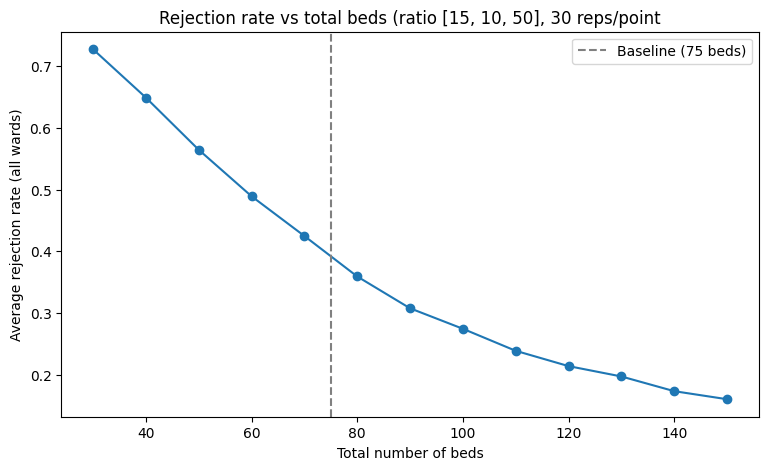

In [193]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(total_beds_range, sweep_mean, marker='o')
#ax.fill_between(total_beds_range, sweep_mean - 1.96 * sweep_se, sweep_mean + 1.96 * sweep_se, alpha=0.2)
ax.axvline(sum(ward_capacities), color='gray', linestyle='--', label=f'Baseline ({sum(ward_capacities)} beds)')
ax.set_xlabel('Total number of beds')
ax.set_ylabel('Average rejection rate (all wards)')
ax.set_title(f'Rejection rate vs total beds (ratio {list(ward_capacities)}, {n_reps_sweep} reps/point')
ax.legend()
plt.show()